In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
csv_file = "/content/drive/MyDrive/DataSets/MSResearch/ModellingDataset/MLRDataset.csv"

In [3]:
csv_file = "/content/drive/MyDrive/DataSets/MSResearch/ModellingDataset/wireless_weather_signal_ph2_modelling_data.csv"

In [4]:
ww_df = pd.read_csv(csv_file)
ww_df.shape

(307527, 18)

In [5]:
ww_df.describe()

,sublink_id,rsl_value,frequency,length,ELEVATION,WND_SPEED_MPS,WND_TYPE_CODE_N,WND_TYPE_CODE_V,VIS_DISTANCE_MTS,SLP_HECTOPASCALS,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,TMP_F,rsl_change_mw
count,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000
mean,53.553184,-59.464795,26752.740003,1748.671921,7.286489,28.169988,0.572662,0.309381,15180.358534,10165.302143,0.104914,0.067978,0.129306,0.267193,0.000351,50.730233,1.031481
std,30.010308,6.858544,26852.703911,1295.359424,13.513326,17.047325,0.494693,0.462239,2699.646463,86.540963,0.306444,0.251708,0.335539,0.442495,0.018737,13.811813,0.330459
min,1.000000,-85.000000,5270.000000,24.500000,2.130000,0.000000,0.000000,0.000000,402.000000,9905.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.040000,0.398107
25%,26.000000,-64.000000,5560.000000,631.400000,2.130000,15.000000,0.000000,0.000000,16093.000000,10108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,41.000000,0.794328
50%,54.000000,-59.000000,5810.000000,1503.400000,2.130000,26.000000,1.000000,0.000000,16093.000000,10163.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.020000,1.000000
75%,80.000000,-55.000000,60480.000000,2791.900000,2.130000,36.000000,1.000000,1.000000,16093.000000,10223.000000,0.000000,0.000000,0.000000,1.000000,0.000000,60.080000,1.258925
max,103.000000,-35.000000,69120.000000,6936.500000,42.700000,77.000000,1.000000,1.000000,16093.000000,10399.000000,1.000000,1.000000,1.000000,1.000000,1.000000,93.920000,1.584893


In [6]:
ww_df = ww_df.drop(columns=['rsl_value', 'sublink_id'])

In [7]:

ww_df.columns

Index(['Datetime', 'frequency', 'length', 'ELEVATION', 'WND_SPEED_MPS',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS',
       'SLP_HECTOPASCALS', 'GD1__1', 'GD1__2', 'GD1__3', 'GD1__4', 'GD1__5',
       'TMP_F', 'rsl_change_mw'],
      dtype='object')

In [8]:
ww_df = ww_df.drop(columns=['Datetime'])

In [9]:
ww_df.iloc[0:10]

,frequency,length,ELEVATION,WND_SPEED_MPS,WND_TYPE_CODE_N,WND_TYPE_CODE_V,VIS_DISTANCE_MTS,SLP_HECTOPASCALS,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,TMP_F,rsl_change_mw
0,60480,222.1,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,0.501187
1,62640,623.0,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,1.258925
2,58320,451.8,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,0.794328
3,60480,222.1,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,1.258925
4,58320,232.6,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,0.501187
5,58320,1808.9,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,0.794328
6,58320,232.6,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,1.000000
7,64800,482.8,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,1.258925
8,58320,451.8,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,1.258925
9,69120,1845.1,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,0.630957


In [ ]:
ww_df_sample = ww_df.sample(frac=0.3, random_state=42)
print(f"Original DataFrame shape: {ww_df.shape}")
print(f"Sampled DataFrame shape: {ww_df_sample.shape}")

Original DataFrame shape: (512001, 7)
Sampled DataFrame shape: (153600, 7)


In [ ]:
ww_df_sample.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'ELEVATION', 'WND_SPEED_MPS', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V',
       'VIS_DISTANCE_MTS', 'SLP_HECTOPASCALS', 'GD1__1', 'GD1__2', 'GD1__3',
       'GD1__4', 'GD1__5', 'TMP_F', 'rsl_change_mw'],
      dtype='object')

In [10]:
ww_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307527 entries, 0 to 307526
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   frequency         307527 non-null  int64  
 1   length            307527 non-null  float64
 2   ELEVATION         307527 non-null  float64
 3   WND_SPEED_MPS     307527 non-null  int64  
 4   WND_TYPE_CODE_N   307527 non-null  int64  
 5   WND_TYPE_CODE_V   307527 non-null  int64  
 6   VIS_DISTANCE_MTS  307527 non-null  int64  
 7   SLP_HECTOPASCALS  307527 non-null  int64  
 8   GD1__1            307527 non-null  int64  
 9   GD1__2            307527 non-null  int64  
 10  GD1__3            307527 non-null  int64  
 11  GD1__4            307527 non-null  int64  
 12  GD1__5            307527 non-null  int64  
 13  TMP_F             307527 non-null  float64
 14  rsl_change_mw     307527 non-null  float64
dtypes: float64(4), int64(11)
memory usage: 35.2 MB


In [11]:
ww_df_sample = ww_df

# Task
Perform multiple linear regression on the `ww_df_sample` DataFrame to predict the 'rsl_change_mw' target variable, using Recursive Feature Elimination (RFE) for feature selection, and evaluate the model's performance using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared.

## Prepare Data for ML

### Subtask:
Separate the features (X) and the target variable (y = 'rsl_change_mw') from the `ww_df_sample` DataFrame.


**Reasoning**:
To separate features and the target variable, I will create a new DataFrame `X` by dropping the target column 'rsl_change_mw' from `ww_df_sample` and create a Series `y` containing only the 'rsl_change_mw' column.



In [12]:
X = ww_df_sample.drop(columns=['rsl_change_mw'])
y = ww_df_sample['rsl_change_mw']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (307527, 14)
Shape of target (y): (307527,)


## Split Data into Training and Testing Sets

### Subtask:
Divide the prepared data into training and testing sets to ensure the model can be evaluated on unseen data. A standard split of 80% for training and 20% for testing will be used.


**Reasoning**:
To divide the data into training and testing sets, I will import the `train_test_split` function from `sklearn.model_selection` and then apply it to `X` and `y` with the specified `test_size` and `random_state`.



In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (246021, 14)
Shape of X_test: (61506, 14)
Shape of y_train: (246021,)
Shape of y_test: (61506,)


## Implement RFE and Multiple Linear Regression

### Subtask:
Apply Recursive Feature Elimination (RFE) using a Linear Regression model to select the most significant features from the training data. Then, train a Multiple Linear Regression model on the training data using only the features selected by RFE.


**Reasoning**:
To perform Recursive Feature Elimination (RFE) and then train a Multiple Linear Regression model, I will first import the necessary `LinearRegression` and `RFE` classes, then initialize RFE with a Linear Regression estimator and fit it to the training data. After selecting features, I will transform the training and test sets and finally fit a new Linear Regression model to the RFE-selected features.



In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

# Initialize Linear Regression model for RFE
estimator = LinearRegression()

# Initialize RFE with the estimator and select 7 features
rfe = RFE(estimator=estimator, n_features_to_select=7)

# Fit RFE to the training data
rfe.fit(X_train, y_train)

# Transform X_train and X_test to retain only selected features
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Get the names of the selected features
selected_features = X.columns[rfe.support_]
print(f"Selected features by RFE: {list(selected_features)}")

# Initialize and train a new Linear Regression model with selected features
linear_model = LinearRegression()
linear_model.fit(X_train_rfe, y_train)

print("RFE applied and Linear Regression model trained successfully.")

Selected features by RFE: ['ELEVATION', 'WND_TYPE_CODE_V', 'GD1__1', 'GD1__2', 'GD1__3', 'GD1__4', 'GD1__5']
RFE applied and Linear Regression model trained successfully.


## Evaluate Regression Model Performance

### Subtask:
Predict on the test set and calculate the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared to assess the performance of the multiple linear regression model.


**Reasoning**:
To evaluate the model's performance, I will first make predictions on the test set, then import the necessary metrics from `sklearn.metrics` and calculate MSE, RMSE, MAE, and R-squared, finally printing each metric.



In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = linear_model.predict(X_test_rfe)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.1081
Root Mean Squared Error (RMSE): 0.3288
Mean Absolute Error (MAE): 0.2701
R-squared (R2): 0.0099


## Final Task

### Subtask:
Summarize the findings from the multiple linear regression analysis, including the selected features and the model's performance metrics.


## Summary:

### Q&A
The multiple linear regression analysis selected 7 features: `ELEVATION`, `WND_TYPE_CODE_V`, `GD1__1`, `GD1__2`, `GD1__3`, `GD1__4`, and `GD1__5`. The model's performance on the test set yielded a Mean Squared Error (MSE) of 0.1081, a Root Mean Squared Error (RMSE) of 0.3288, a Mean Absolute Error (MAE) of 0.2701, and an R-squared of 0.0099.

### Data Analysis Key Findings
*   The initial dataset `ww_df_sample` contained 307,527 samples and 14 features before splitting, with 'rsl\_change\_mw' as the target variable.
*   The data was split into training (80% or 246,021 samples) and testing (20% or 61,506 samples) sets.
*   Recursive Feature Elimination (RFE) identified 7 features as most significant for predicting 'rsl\_change\_mw': `ELEVATION`, `WND_TYPE_CODE_V`, `GD1__1`, `GD1__2`, `GD1__3`, `GD1__4`, and `GD1__5`.
*   The multiple linear regression model, trained using these 7 features, demonstrated a very low predictive power, with an R-squared value of only 0.0099 on the test set, indicating that less than 1% of the variance in the target variable is explained by the model.
*   The error metrics for the model were MSE: 0.1081, RMSE: 0.3288, and MAE: 0.2701.

### Insights or Next Steps
*   The current multiple linear regression model exhibits extremely poor explanatory power for `rsl_change_mw`, as indicated by the R-squared value of approximately 0.01. This suggests that the relationship between the selected features and the target variable is largely non-linear or that critical explanatory variables are missing from the current feature set.
*   Future steps should involve exploring more sophisticated feature engineering, investigating non-linear regression models (e.g., polynomial regression, tree-based models), or identifying additional relevant features that might have a stronger predictive relationship with `rsl_change_mw`.


In [16]:
ww_df.columns

Index(['frequency', 'length', 'ELEVATION', 'WND_SPEED_MPS', 'WND_TYPE_CODE_N',
       'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS', 'SLP_HECTOPASCALS', 'GD1__1',
       'GD1__2', 'GD1__3', 'GD1__4', 'GD1__5', 'TMP_F', 'rsl_change_mw'],
      dtype='object')

## Visualize Predicted vs. Actual Values

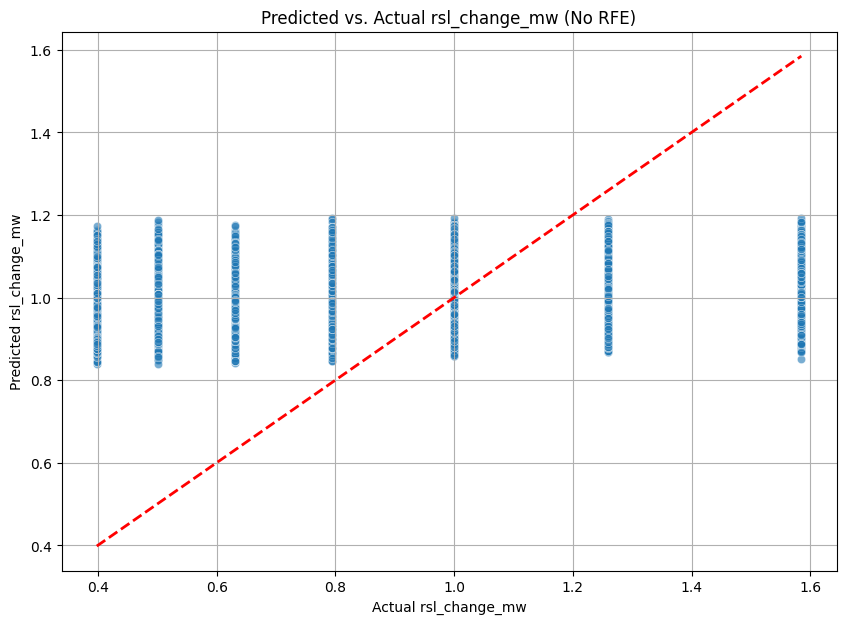

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_no_rfe, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual rsl_change_mw')
plt.ylabel('Predicted rsl_change_mw')
plt.title('Predicted vs. Actual rsl_change_mw (No RFE)')
plt.grid(True)
plt.show()

## Plot Predicted vs. Actual Values (Line Plot)

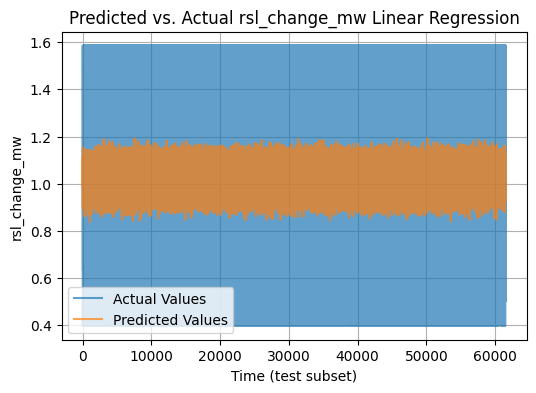

In [22]:
plt.figure(figsize=(6, 4))
# Plotting actual values
plt.plot(y_test.values, label='Actual Values', alpha=0.7)
# Plotting predicted values
plt.plot(y_pred_no_rfe, label='Predicted Values', alpha=0.7)

plt.title('Predicted vs. Actual rsl_change_mw Linear Regression')
plt.xlabel('Time (test subset)')
plt.ylabel('rsl_change_mw')
plt.legend()
plt.grid(True)
plt.show()

## Implement Multiple Linear Regression (without RFE)

### Subtask:
Train a Multiple Linear Regression model on the training data without performing feature selection.


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train a Linear Regression model on the full training data
linear_model_no_rfe = LinearRegression()
linear_model_no_rfe.fit(X_train, y_train)

print("Linear Regression model trained successfully without RFE.")

# Make predictions on the test set using the model without RFE
y_pred_no_rfe = linear_model_no_rfe.predict(X_test)

# Calculate performance metrics for the model without RFE
mse_no_rfe = mean_squared_error(y_test, y_pred_no_rfe)
rmse_no_rfe = np.sqrt(mse_no_rfe)
mae_no_rfe = mean_absolute_error(y_test, y_pred_no_rfe)
r2_no_rfe = r2_score(y_test, y_pred_no_rfe)

# Print the metrics
print(f"\nPerformance of Linear Regression model without RFE:")
print(f"Mean Squared Error (MSE): {mse_no_rfe:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_no_rfe:.4f}")
print(f"Mean Absolute Error (MAE): {mae_no_rfe:.4f}")
print(f"R-squared (R2): {r2_no_rfe:.4f}")

Linear Regression model trained successfully without RFE.

Performance of Linear Regression model without RFE:
Mean Squared Error (MSE): 0.1063
Root Mean Squared Error (RMSE): 0.3260
Mean Absolute Error (MAE): 0.2680
R-squared (R2): 0.0264
